In [1]:
import numpy as np;
from tensorflow.keras.datasets import mnist;
import random as rnd;
import sys;
import math;
import matplotlib.pyplot as plt

In [ ]:

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

def normalize_and_vectorize_image(image: np.array):
    """
    Turn a image of variable dimesions (must be square) into a vector and normalize values between 0 and 1
    """
    flat = image.flatten()

    maximum = np.max(flat)
    normalised: np.array = flat / maximum

    return normalised.astype(np.half)

train_images_vectored = np.array([normalize_and_vectorize_image(img) for img in train_images])
test_images_vectored = np.array([normalize_and_vectorize_image(img) for img in test_images])

def bin_image(image, threshold = 122):
    """
    Turn an image into it's binned version with unit8's of values 1 and 0. threshold determines below what values a pixel is condicered empty (0)
    """
    size = len(image)
    binned_image = np.zeros((size,size), dtype="uint8")
    for y_i, y_val in enumerate(image):
        for x_i, x_val in enumerate(y_val):
            if x_val > threshold:
                binned_image[y_i, x_i] = 1
            else:
                binned_image[y_i, x_i] = 0
    return binned_image

def binary_encode_np(image):
    image = bin_image(image)
    return np.packbits(image)

def binary_decode_np(encoded_image):
    unpacked = np.unpackbits(encoded_image)
    size = int(math.sqrt(len(unpacked)))
    return unpacked[: size**2].reshape((size, size))

train_images_binned = [(binary_decode_np(binary_encode_np(im))) for im in train_images]
test_images_binned = [(binary_decode_np(binary_encode_np(im))) for im in test_images]

def order_by_number(dataset_images, dataset_labels):
    """
    Order dataset by labels to that every unique label has a list of values that share the label.
    """
    ordered_images = {0: [], 1: [], 2:[], 3:[], 4:[], 5:[], 6:[], 7:[], 8:[], 9:[]}
    for i, _ in enumerate(dataset_images):
        if (len(ordered_images[dataset_labels[i]]) > 89): # addition since previous version. a limitor for the amount of images.
            continue
        ordered_images[dataset_labels[i]].append(dataset_images[i])
    return ordered_images

ordered_images = order_by_number(train_images_binned, train_labels)

# Onderzoek MNIST nummer herkenning

## Inhoud
- 1 inleiding
- 2 data begrijpen
- 3 encoding
- 4 feature engineering
- 5 model/algoritme keuze
- 6 eindkeuze
- 7 relectie
- 8 taakverdeling

## 1. Inleiding
In het vak Datastructures and alogirthms zijn in de afgelopen weken verschillende voorspellings algoritmen behandeld. Deze zijn ingezet om getallen uit de mnist dataset te herkennen. In deze slotopdracht wordt een overzicht gemaakt. Hierbij staat de vraag centraal:\
__Welk algoritme is het best geschikt voor cijferherkenning, runnend op de mystery device?__\
De mystery device heeft de volgende specs
- 256 kb ram
- 1 mb opslag

## 2. Data begrijpen

__Wat MNIST is__\
MNIST is een gelabelde dataset van 70000 afbeeldingen van handgeschreven cijfers.
De Mnist dataset in ontwikkeld aan het eind van de jaren 80 als 'objective' maatstaf voor het bepalen van naukeurigheid van cijferherkenningsprogramma's voor de Amerikaanse overheid. Deze noodzaak was ontstaan door lastig te vergelijken claims van verschillende aanbieders van dit soort software. Vaak met als doel automatisch overheidsformulieren in te lezen.

__figuur 1__ Een selectie van MNIST afbeeldingen

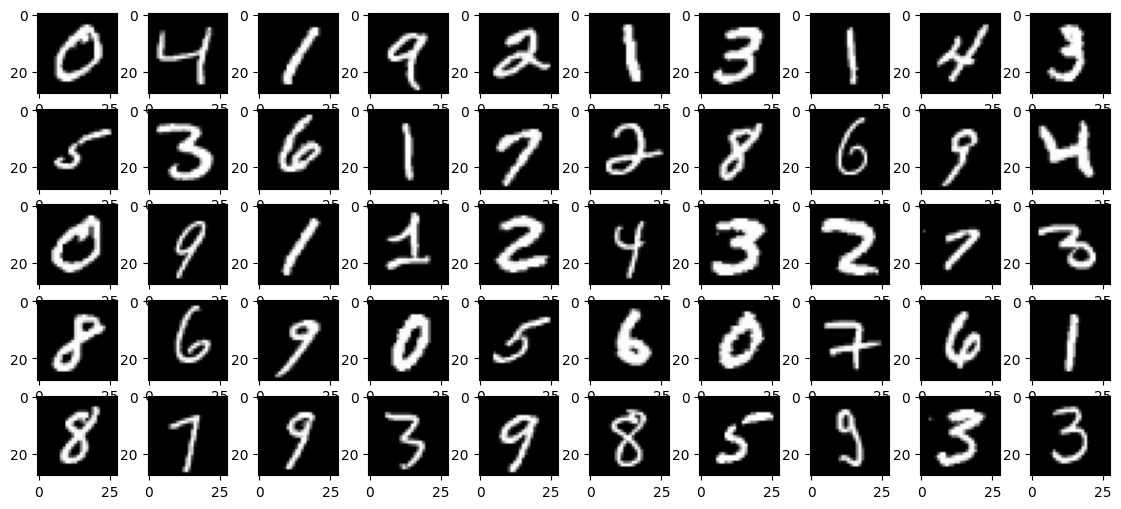

In [3]:
fig = plt.figure(figsize=(14, 6))
columns = 10
rows = 5
for i in range(1, columns*rows +1):
    img = train_images[i]
    fig.add_subplot(rows, columns, i)
    plt.imshow(img, cmap="grey")
plt.show()

__MNIST in cijfers__\
afbeeldingen: 70000 stuks\
afmetingen afbeelding: 28*28 pixels\
verdeling cijfers:



In [4]:
def order_by_number_whole_dataset(dataset_images, dataset_labels):
    """
    Order dataset by labels to that every unique label has a list of values that share the label.
    """
    ordered_images = {0: [], 1: [], 2:[], 3:[], 4:[], 5:[], 6:[], 7:[], 8:[], 9:[]}
    for i, _ in enumerate(dataset_images):
        ordered_images[dataset_labels[i]].append(dataset_images[i])
    return ordered_images

for k, v in order_by_number_whole_dataset(np.append(test_images, train_images, axis=0), np.append(test_labels, train_labels)).items():
    print(f"{k} amount: {len(v)}")

0 amount: 6903
1 amount: 7877
2 amount: 6990
3 amount: 7141
4 amount: 6824
5 amount: 6313
6 amount: 6876
7 amount: 7293
8 amount: 6825
9 amount: 6958


cijfers zijn in greyscale iedere pixel heeft een waarde van 0-255.

__lastige cijfers__\
sommige cijfers worden gemakkelijker herkent dan anderen.
In voorgaande opdrachten is gebleken dat de 4 en 9 vaak verward worden.

Het valt op dat cijfers die vaak hetzelfde lijken gemakkelijker worden herkent. de 0 en 1 scoren bijvoorbeeld vaak hoog. Verder valt op dat de afbeeldingen zo zijn gemaakt dat het cijfer altijd goed in het midden past. Ondanks dat de MNIST dataset uit 70000 afbeeldingen bestaat zijn sommige pixels nooit gebruikt.

Welke informatie belangrijk is voor het herkennen van een cijfer is lastig te zeggen. Dit is namelijk sterk afhankelijk van de methode waarmee een afbeelding wordt herkent. In de hiervoor gemaakt oprachten blijkt echter dat de beste manier om een afbeelding te voorspellen het gebruiken van de afbeelding zelf is. Over het algemeen blijken geagregeerde gegevens weinig toegeveogde waarde te hebben in de alogoritmen met de hoogste accuracy. Daarnaast heeft een pixelwaarde range van 0-255 weinig effect op de voorspelde waarden.

__Design keuzes__\
Op grond van deze gegevens zijn de volgende keuzes gemaakt.
1. Voor een goede herkenning van cijfers die zelf getekend zijn (en dus niet voldoen aan de MNIST preprocessing) is het van belang zelf een extra preprocessor toe te voegen op de mystery device die de gegeven afbeelding schaalt zodat deze beter binnen de bestaande datapatronen past.
2. Het valt op dat kleurverloop in de afbeeldingen vaak van beperkte toegevoegde waarde is, Zie opdracht van week 3, zie hoofstuk 'Hoeveel afbeeldingen passen op de mystery device?'. Daarom wordt binning ingezet om afbeeldingrote te reduceren in de alogritmen waar dit zinvol is.
3. Om nieuwe afbeeldingen te gebruiken zal op de mystery device een inlees systeem moeten worden ontwikkeld.
Welk algoritme zal worden gebruikt wordt in volgende hoofstukken behandeld.





## 3. Encoding
Welke encoding wordt gebuikt is afhankelijk van welk alogritme wordt gebruikt. Het doel is hierbij telkens een encoding te kiezen waarmee zo hoog mogelijke accuary kan worden bereikt.


### Prestaties van verschillende compressie algoritmen
Gegevens komen uit P opdracht van week 4


In [5]:
# Verschillende compression methods, gemaakt in week 4.
def binary_encode(image):
    bin_image = bytearray()

    binary_secion: str = ""
    for row in image: # write pixel data one by one
        for pixel in row:
            if pixel > 50:
                binary_secion += "1"
            else:
                binary_secion += "0"

            if len(binary_secion)  == 8:
                encoded_section = int(binary_secion, 2)
                bin_image.append(encoded_section)
                binary_secion = ""

    return bytes(bin_image)

def binary_decode(binary: bytes, size = 28):
    binaries = ""
    for byte in binary:
        binary_section = bin(byte)[2:].zfill(8)
        binaries += binary_section
    one_d_image = []
    for px in binaries:
        one_d_image.append(int(px) * 255)
    image = np.reshape(one_d_image, (size, size))

    return image

def bin_image(image, threshold = 122):
    """
    Turn an image into it's binned version with unit8's of values 1 and 0. threshold determines below what values a pixel is condicered empty (0)
    """
    size = len(image)
    binned_image = np.zeros((size,size), dtype="uint8")
    for y_i, y_val in enumerate(image):
        for x_i, x_val in enumerate(y_val):
            if x_val > threshold:
                binned_image[y_i, x_i] = 1
            else:
                binned_image[y_i, x_i] = 0
    return binned_image


def binary_encode_np(image):
    image = bin_image(image)
    return np.packbits(image)

def binary_decode_np(encoded_image):
    unpacked = np.unpackbits(encoded_image)
    size = int(math.sqrt(len(unpacked)))
    return unpacked[: size**2].reshape((size, size))

def compres_image(image, new_size = 14):
    """
    Reduce the resolution of an image
    """
    originial_size = len(image)
    step = originial_size / new_size
    steps = [s * step for s in range(new_size)]
    new_image = np.zeros((new_size, new_size), dtype="uint8")
    y_i = 0
    for block_y_start in steps:
        block_y_end = block_y_start + step
        x_i = 0
        for block_x_start in steps:
            block_x_end = block_x_start + step
            block = image[int(block_y_start) : int(block_y_end), int(block_x_start): int(block_x_end)]
            pixel_color = np.average(block)
            new_image[y_i, x_i] = pixel_color
            x_i += 1
        y_i += 1
    return new_image

def encode_counting(image):
    result = np.zeros((0), dtype="uint8")
    length_of_color = 0
    is_white = image[0,0] != 0

    for y_i, row in enumerate(image):
        for x_i, pixel in enumerate(row):
            is_pixel_white = pixel != 0
            if (is_pixel_white == is_white):
                length_of_color += 1
            else:
                result = np.append(result, length_of_color)
                length_of_color = 1
                is_white = is_pixel_white
    result = np.append(result, length_of_color)

    return result


def decode_counting(encoded):
    result = np.zeros((0), dtype="uint8")
    is_white = False  # technical dept should be dynamic
    for section in encoded:
        result_section = np.full((section), int(is_white))
        is_white = not is_white
        result = np.concat((result, result_section))
    size = int(math.sqrt(len(result)))
    print(size)
    result = result[:size**2]
    result = result.reshape((size, size))
    return result

empty array size: 72


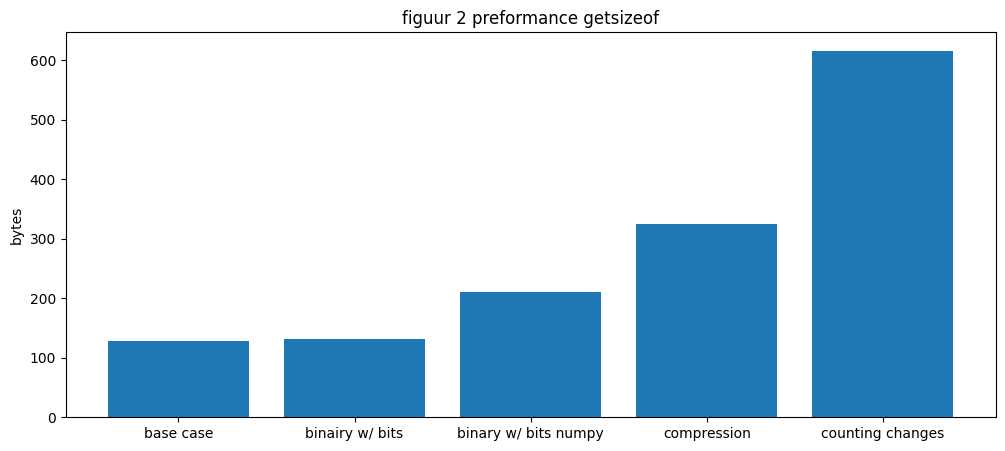

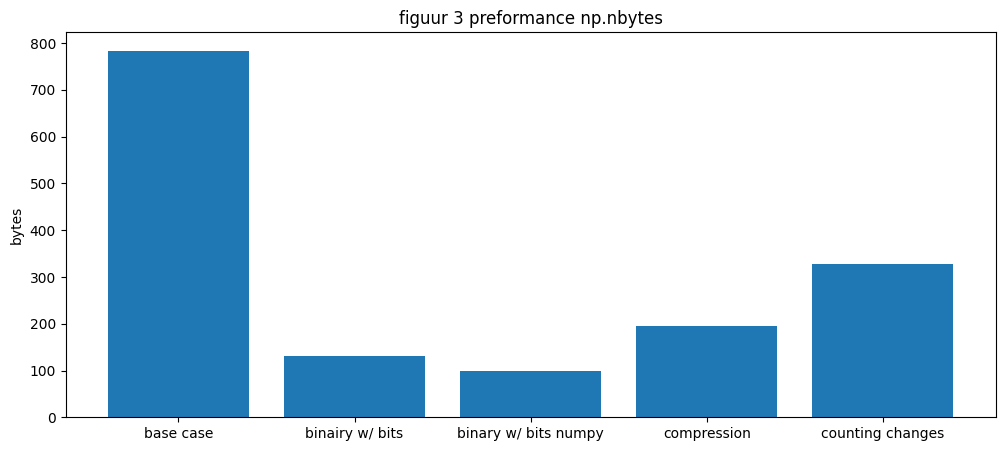

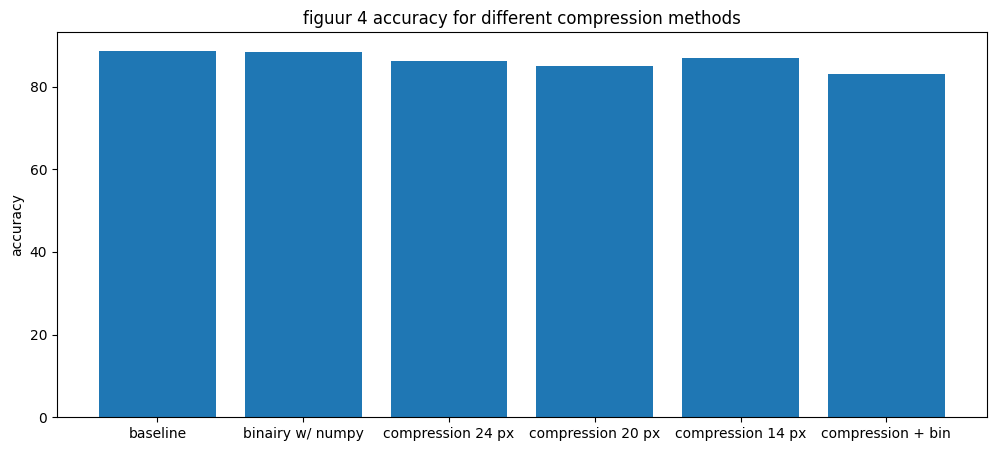

In [27]:
# results
fig, ax = plt.subplots()

print("empty array size:", sys.getsizeof(np.array))

encoding_techique = ['base case',
                     'binairy w/ bits',
                     'binary w/ bits numpy',
                     "compression",
                     "counting changes"]
counts = [
    sys.getsizeof(train_images[20]),
    sys.getsizeof(binary_encode(train_images[20])),
    sys.getsizeof(binary_encode_np(train_images[20])),
    sys.getsizeof(compres_image(train_images[20])),
    sys.getsizeof(encode_counting(train_images[20]))]

ax.bar(encoding_techique, counts)

ax.set_ylabel('bytes')
ax.set_title('figuur 2 preformance getsizeof')
fig.set_size_inches((12, 5))



fig, ax = plt.subplots()

encoding_techique = ['base case',
                     'binairy w/ bits',
                     'binary w/ bits numpy',
                     "compression",
                     "counting changes"]
counts = [
    train_images[40].nbytes,
    sys.getsizeof(binary_encode(train_images[40])),
    binary_encode_np(train_images[40]).nbytes,
    compres_image(train_images[40]).nbytes,
    encode_counting(train_images[40]).nbytes]

ax.bar(encoding_techique, counts)

ax.set_ylabel('bytes')
ax.set_title('figuur 3 preformance np.nbytes')
fig.set_size_inches((12, 5))

plt.show()

fig, ax = plt.subplots()
encoding_techique = ['baseline',
                     'binairy w/ numpy',
                     "compression 24 px",
                     "compression 20 px",
                     "compression 14 px",
                     "compression + bin"]
counts = [
    88.7,
    88.3,
    86.2,
    85,
    87,
    83


    ]

ax.bar(encoding_techique, counts)

ax.set_ylabel('accuracy')
ax.set_title('figuur 4 accuracy for different compression methods')
fig.set_size_inches((12, 5))

plt.show()

Op basis van deze prestaties wordt de geconculdeerd dat binair binnen tot weinig dataverlies leid terwijl de memory footprint drastisch wordt gereduceerd. Daarom wordt deze vorm van compression ingezet. Daarmee kunnen meer afbeeldingen worden opgeslagen. Dit is extra voordelig bij algoritmen die baat hebben bij het opslaan van zo veel mogelijk afbeeldingen, zoals K-NN en K-means.

### Hoe veel abeeldingen passen er op de mystery device?

Voor k-nn en k-means is de groote van het model vrijwel geheel ingegeven door de groote van de afbeeldingen die moeten worden opgeslagen. Hoe meer afbeeldingen hoe naukeuriger het model wordt. Dus dan ontstaat de vraag, hoe veel afbeeldingen passen op de mystery device?

Op basis van eerder onderzoek in week 4 wordt de keuze gemaakt om gebruikt te maken van binning. Want deze zorgt voor een significante daling in het geheugengebruik met een minimale daling in de accuracy.\
Voor Er wordt verder gerekend met de zelf gemaakte binning om geheugengebruik te bepalen (omdat deze de overhead van de datasctuctuur meerekend) iets wat niet wordt gedaan bij numpy.\
Hierbij komen we uit op een geheugengebruik van 131 bytes.
256 kb bevat\
256_000 bytes\
Dat zijn dus 256_000 / 131 = __1.954.2 afbeeldingen__

Daarom is het voor de k-nn en k-means alogritmen een maximum van 190 prototypes * 10 verschilledende digits te gebruiken. Het is ecther gebleken dat het gebruiken van het maximale aantal afbeeldingen inzetten niet leid tot de hoogst mogelijke accuracy. Zowel het week 3 ding als bij K-NN is naukeuriger bij 90 * 10 prototypes.

## memory footprint van python

De memory footprint van python is groot. Dit blijkt uit een onderzoek met behulp van een docker container. In dit korte hoofdstuk wordt uitgelegd hoe dit is bepaald.

Een docker container is gemaakt met behulp van `docker run --rm -p 8889:8888 -v "$(pwd):/home/jovyan/work" quay.io/jupyter/base-notebook start-notebook.py --NotebookApp.token='my-token'` In docker desktop kunnen vervolgens de gebruikte resources in kaart gebracht worden.\
De base load is 80 mb. Na het runnen van een eenvoudig script `print("Hello World")` stijgt de load naar 160 mb. Het runnen van de activatie functies opdracht binnen deze omgeving zorgt voor een constante load (ook na runnen) van 1.6 gb.

Op basis van deze bevindingen wordt geconcludeerd dat het onmogelijk is de gehele applicatie binnen de 256kb ram te kunnen runnen.

Daarom is besloten alleen de memory footprint voor de opslag van een model bij te houden. 

## Features

In de desicion tree opdracht zijn de volgende features ontwikkeld:

- check_center (hoe opgevuld het midden is)
- vertical_symmetry (mate van symetrie op verticale as)
- horizontal_symmetry (mate van symetrie op horizonale as)
- top_bottom_balance (verhouding gevulde pixels boven en onder)
- pixel_density (gemiddelde waarde van afbeelding)
- left_right_balance (verhouding gevulde pixels links en rechts)
- active_pixels (aantal pixels met waarde boven threshold)

De ontwikkelde agregaat features hebben vrijwel geen meerwaarde in het voorspellen van nummers.
In de opdracht P3 eigen decission tree zijn verschillende features ontwikkeld. In diezelfde opdracht is daarmee een accuracy van 27.8% mee bereikt. In vervolgopdrachten zijn deze features herhaaldelijk terug gekomen. Vaak bleken deze een zeer gering positive en soms zelfs negatieve uitwerking te hebben op het voorspellend vermogen.

Omdat features geen of nauwelijks toegevoegde waarde blijken te hebben is daarom de keuze gemaakt aggregaat features niet verder in te zetten in het onderzoek.

## Algoritme keuze
### Overzicht bestaande data

De verschillende toegepaste alogritmes zijn:

- Handgemaakte decision tree
- week 3 ding
- k-nearest neigbor
- k-means
- linear regression
- decision tree gemaakt met gini
- neuraal netwerkt met keras
- neuraal netwerkt handgemaakt

### Uitleg verschillende algoritmen
Hieronder wordt een korte uitleg gegeven van de verschillende algoritmen.
__Handgemaakte decision tree__: Een aantal agregaat features worden door een grote if/else if/elke keten gehaalt. Een latere aanpassing bleek beter resultaat te geven. Hierbij worden de outputs van features vergeleken met eerdere output van deze features. Vervolgens krijgt een nummer een punt als de feature het meest met het gemiddelde van dit getal overeen komt. Zo wordt door een lijst van features heen gegaan en kan uit eindelijk een meest waarschijnlijk getal worden gegeven.\
__data__: Model data opgeslagen als dict, input als 2d numpy array.

__week 3 ding__: Een zelf bedacht algoritme. Deze maakt een som van alle verschillen tussen de bekende afbeeldingen en de gegeven afbeelding. Vervolgens wordt het cijfer voorspeld die het kleinste verschil heeft.\
__data__: Model data opgeslagen als ordered numbers dict, input als 2d numpy array.

__k-nearest neigbor__: K-nearest neighbor zoekt de afbeeldingen die het meest lijken op de gegeven afbeelding. Vervolgens wordt het nummer voorspeld dat het vaakst terugkomt in deze nabij gelegen andere afbeeldingen (de buren).\
__data__:Model data opgeslagen als ordered numbers dict, input als 2d numpy array.

__k-means__: K means zoekt naar clusters in data. Kort door de bocht kan worden gezegd dat K-means de meest representative afbeeldingen maakt voor ieder cijfer. Vervolgens wordt het dichtst bijzijnde prototype van de gegeven afbeelding gezocht.\
__data__:Model data als ordered numbers dict, input als 2d numpy array.

__linear regression__: Linear regression is een vreemde keuze voor classificatieproblemen. Want linear regression zoekt een linear verband in een dataset (puntenwolk). In dit geval zoekt linear regression naar een verband tussen alle individuele pixelwaarden en of een afbeelding wel (1) of niet (0) een nummer representeerd. Vervolgens wordt de voorspelling met de meeste zekerheid gekozen.\
__data__: Model data opgeslagen in geimporteerde type, input als 2d numpy array.

__decision tree gemaakt met gini__: In tegenstelling tot de handgemaakte decision tree is deze machinaal gecontrueerd. Gini is een maatstaf voor de zuiverheid van data. Het doel bij het maken van de decision tree is dan het minimaliseren van de onzuiverheden in alle lagen (de dataset zo snel mogelijk zo zuiver mogelijk krijgen).\
__data__: Model data opgeslagen in geimporteerde type, input als 2d numpy array.

__neuraal netwerkt met keras__: Een neuraal netwerk maakt een beslissing op basis van wegingsfactoren en activation functions. Een input wordt door verschillende lagen van een neuraal netwerk heen geleid. In iedere laag worden inputs vermenigvuldigd met wegingsfactoren, ook wordt er een bias bij opgetelt. Daarna wordt een activator function ingezet, dit is een (vaak) eenvoudige functie (zoals RELU). Om het model goede voorspellingen te laten doen worden de wegingen in backpropegation aangepast om voorspelling te verbeteren.\
In dit geval is gebruik gemaakt van de library keras om het neuraal netwerk te bouwen.\
__data__: Model data opgeslagen in geimporteerde type, input als 2d numpy array.

__neuraal netwerkt handgemaakt__: Een neuraal netwerk maakt een beslissing op basis van wegingsfactoren en activation functions. Een input wordt door verschillende lagen van een neuraal netwerk heen geleid. In iedere laag worden inputs vermenigvuldigd met wegingsfactoren, ook wordt er een bias bij opgetelt. Daarna wordt een activator function ingezet, dit is een (vaak) eenvoudige functie (zoals RELU). Om het model goede voorspellingen te laten doen worden de wegingen in backpropegation aangepast om voorspelling te verbeteren.\
In dit geval is gebruik gemaakt van een handgemaakt neuraal netwerk.\
__data__: Model opgeslagen als np.ndarray, input als 2d numpy array



### Prestaties van de algoritmen
Eerst wordt onderzocht wat de hoogste accuracy is die ooit is gehaalt met deze techniek in het project. Daarna wordt onderzocht of de huidige implementatie op de mystery device past. Tot slot wordt de beste prestatie gegeven die binnen de perken van de mystery device past.\
Zoals besproken in "Encoding/memory footprint van python" wordt alleen gekeken naar de memory footprint van het model. Hoe veel geheugen wordt gebruikt tijdens het runnen wordt buiten beschouwing gelaten. Evenals overhead van NumPy en Python.
De resultaten van tabel 1 tonen al bekende gegevens op basis van eerder opdrachten.

__best passende prestatie__\
Voor het bepalen van de best passende prestatie wordt het model op zo'n manier geconfiguureerd dat deze past op de mystery device.

__tabel 1__ vergelijking algoritmen
algoritme | Handgemaakte d tree |week 3 ding| k-nearest neighbor | k-means | linear regression | gini d tree | nn keras | nn handgemaakt|
----------|---------------------|-----------|--------------------|---------|-------------------|-------------|----------|---------------|
accuracy top| 27.8%             |72%        | onbekend           | 93%     | 86.0%             | 88.0%       | 97%      | 98%           |
past op mystery device| ja      |nee        | onbekend           | afhankelijk| onbekend       | onbekend    | ja       | nee           |
beste passende prestaties| 27.8%|onbekend   | onbekend           | 88.3    | onbekend          | onbekend    | 79.5%    | onbekend      |

### Vervolg onderzoek

Zoals te zien is in tabel 1 zijn een aantal opties niet voledig afgewogen. In dit onderdeel worden deze onzekerheden weggewerkt zodat een voledige tabel ontstaat.

#### week 3 ding

In de opdracht van week 3 is een implementatie ontwikkeld die wat wegheeft van k-nearest neigbor. er wordt een accuracy van 57% gehaalt op op de test dataset.

In [7]:
def calculate_min_differances(image):
    likeness  = {0: 999999999, 1: 999999999, 2: 999999999, 3: 999999999, 4: 999999999, 5: 999999999, 6: 999999999, 7: 999999999, 8: 999999999, 9: 999999999}
    for number in ordered_images:
        comparers = ordered_images[number]
        for compareable in comparers:
            differance = np.sum(np.absolute(image - compareable))
            if likeness[number] > differance:
                likeness[number] = differance
    return likeness

In [8]:
count = 0
mistakes = 0;
for i, _ in enumerate(test_images_binned):
    count += 1
    if count > 5000:
        break;
    differances = calculate_min_differances(test_images_binned[i])
    guess = min(differances, key=differances.get)
    if (guess != test_labels[i]):
        mistakes += 1
print("Finished!")
print(f"mistakes: {mistakes}")
print(f"accuracy {mistakes / count * 100}")



Finished!
mistakes: 2700
accuracy 53.98920215956808


accuracy is bij 190 afbeeldingen lager dan bij 90 afbeeldingen.
Bij 190 -> 60%
Bij 190 -> 54%

#### K-NN

In [9]:
# K-NN
def knn(image, K=5):
    likeness = {}
    for number in ordered_images:
        comparers = ordered_images[number]
        for compareable in comparers:
            likeness[number] = np.sum(np.absolute(image - compareable))
    likeness = dict(sorted(likeness.items()))
    # print(likeness)
    most_occurance = {0: 0, 1: 0, 2: 0, 3:0, 4:0, 5:0, 6:0, 7:0, 8:0, 9:0}
    for i in range(K):
        most_occurance[list(likeness.keys())[i]] += 1
    return most_occurance

In [10]:
count = 0
mistakes = 0
for i, _ in enumerate(test_images_binned):
    count += 1
    if count > 5000:
        break;
    differances = knn(test_images_binned[i])

    guess = max(differances, key=differances.get)
    if (guess != test_labels[i]):
        mistakes += 1
print("Finished!")
print(f"mistakes: {mistakes}")
print(f"accuracy {mistakes / count * 100}")

Finished!
mistakes: 4540
accuracy 90.78184363127374


#### K-means

In [34]:
import math;
from random import choices;
import numpy as np;
import matplotlib.pyplot as plt;


def order_by_number(dataset_images, dataset_labels):
    """
    Seperate the mnist dataset into a dictionary ordered by label
    """
    ordered_images = {0: [], 1: [], 2:[], 3:[], 4:[], 5:[], 6:[], 7:[], 8:[], 9:[]}
    for i, _ in enumerate(dataset_images):
        ordered_images[dataset_labels[i]].append(dataset_images[i])
    return ordered_images


def dist(a: np.array, b: np.array):
    """
    calculate the distance between two points in N-dimensional space
    """
    abs_differances = np.abs(a - b)
    dist = math.sqrt(np.sum(abs_differances**2))
    return dist


def k_means(datapoints: tuple[np.array], clusters_amount: int) -> set[tuple]:
    """
    Find the cluster centers
    """
    clusterOrigins: np.array[np.array] = np.array(choices(datapoints, k=clusters_amount), dtype=np.half)
    new_origins = list()
    while True:

        clusters = dict()

        # reassign points to cluster_origins
        for point in datapoints:
            closest_cluster = min(clusterOrigins, key=lambda c : dist(c, point))

            closest_cluster = closest_cluster.tobytes()
            if (closest_cluster not in clusters.keys()):
                clusters[closest_cluster] = list()

            clusters[closest_cluster].append(point)

        # recalcuate origins
        new_origins.clear()
        for key in clusters:
            mean = np.mean(clusters[key], axis=0)
            new_origins.append(mean)

        # base case
        if np.array_equal(np.array(new_origins, dtype=np.half), clusterOrigins):
            return new_origins
        clusterOrigins = new_origins


def vector_to_image(vector: np.array):
    """
    Turn a vector into an image
    """
    length = len(vector)
    width = int(math.sqrt(length))
    square_vector = vector[:width**2]
    image = np.reshape(square_vector, (width, width))
    return image


def show_image(image):
    """
    Show a greyscale square image of any resolution. Image is stored in 2d array.
    """
    plt.imshow(image, cmap="grey")
    plt.show()

def make_prototype(train_images, train_labels, prototypes_per_number: int):
    ordered_images = order_by_number(train_images, train_labels)
    prototype: dict[int: np.array] = dict()
    for num in ordered_images:
        prototype[num] = k_means(ordered_images[num], prototypes_per_number)
        print(f"finished for number {num}")
    print("finished computing prototypes")
    return prototype

def get_distance(a: np.array, b: np.array):
    return dist(a, b)

def predict(image, prototypes):
    img_vector = normalize_and_vectorize_image(image)
    likeness  = {0: 999999999, 1: 999999999, 2: 999999999, 3: 999999999, 4: 999999999, 5: 999999999, 6: 999999999, 7: 999999999, 8: 999999999, 9: 999999999}
    for number in prototypes:
        prototypes_values = prototypes[number]
        for prototype in prototypes_values:
            differance = dist(prototype, img_vector)
            if likeness[number] > differance:
                likeness[number] = differance
    return min(likeness, key=lambda k: likeness[k])

def determine_accuracy(prototypes, images, labels):
    total = len(images)
    misses = 0
    miss_for_num: dict  = {0: 0, 1: 0, 2:0, 3:0, 4:0, 5:0, 6:0, 7:0, 8:0, 9:0}
    for i, image in enumerate(images):
        prediction = predict(image, prototypes)
        # print(f"pred: {prediction} | act: {labels[i]}")
        if prediction != labels[i]:
            misses += 1
            miss_for_num[labels[i]] += 1
    print(f"misses {misses}")
    print(f"accuracy {(total - misses) / total * 100} %")
    print(miss_for_num)



In [ ]:
prototypes = make_prototype(train_images_binned, train_labels, 25)

In [ ]:
determine_accuracy(prototypes, test_images_binned, test_labels)

#### Linear Regression

In [ ]:
# code gekopieërd uit P8
from sklearn.linear_model import LinearRegression


def normalize_image(image: np.array):
    """
    normalize values between 0 and 1
    """

    maximum = np.max(image)
    normalised: np.array = image / maximum

    return normalised


def normalize_and_vectorize_image(image: np.array):
    """
    Turn a image of variable dimesions (must be square) into a vector and normalize values between 0 and 1
    """
    flat = image.flatten()

    maximum = np.max(flat)
    normalised: np.array = flat / maximum
    return normalised


def train_linear_model(X_train, y_binary):
    model = LinearRegression()
    model.fit(X_train, y_binary)
    print(f"coef {model.coef_.shape}")
    return model


def train_linear_model(X_train, y_binary):
    model = LinearRegression()
    model.fit(X_train, y_binary)
    return model

def determine_accuracy(prototypes, images, labels):
    total = len(images)
    misses = 0
    miss_for_num: dict  = {0: 0, 1: 0, 2:0, 3:0, 4:0, 5:0, 6:0, 7:0, 8:0, 9:0}
    for i, image in enumerate(images):
        prediction = predict(prototypes, image)
        # print(f"pred: {prediction} | act: {labels[i]}")
        if prediction != labels[i]:
            misses += 1
            miss_for_num[labels[i]] += 1
    print(f"misses {misses}")
    print(f"accuracy {(total - misses) / total * 100} %")
    print(miss_for_num)


def predict(models, image):
    results = {}
    for i in models:
        results[i] = models[i].predict([image])
    best_fit = max(results, key= lambda k: results[k])
    return best_fit



from sklearn.linear_model import LinearRegression

def train_linear_model(X_train, y_binary) -> LinearRegression:
    model = LinearRegression()
    model.fit(X_train, y_binary)
    return model



def train_numbers(train_images, train_labels):
    models = {}
    for num in range(10):
        models[num] = train_linear_model(train_images, [label == num for label in train_labels])
        print(f"finished for {num}")
    return models

models = train_numbers(train_images_vectored, train_labels)

determine_accuracy(models, test_images_vectored, test_labels)

finished
finished for 0
finished for 1
finished for 2
finished for 3
finished for 4
finished for 5
finished for 6
finished for 7
finished for 8
finished for 9
misses 1398
accuracy 86.02 %
{0: 36, 1: 28, 2: 219, 3: 131, 4: 101, 5: 233, 6: 83, 7: 144, 8: 215, 9: 208}


In [17]:
from pickle import dumps

def kb_size(obj):
    return sys.getsizeof(dumps(obj)) / 1000

print(kb_size(models))

127.195


Het blijkt dat het model met 127.195 kb net binnen het ramgeheugen past. Hiermee wordt aan de opdracht interpretatie voldaan dat alleen het model op het ram geheugen moet passen.


#### gini d tree

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.datasets import mnist;

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images_flattend = train_images.reshape((60_000, 784))
test_images_flatted = test_images.reshape((10_000, 784))

dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=20,
    random_state=42
)

dt.fit(train_images_flattend, train_labels)

y_pred = dt.predict(test_images_flatted)


acc = accuracy_score(y_pred, test_labels)
print("Decision Tree Accuracy on MNIST:", acc)

print("\nClassification Report:")
print(classification_report(y_pred, test_labels))

Decision Tree Accuracy on MNIST: 0.8818

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      1008
           1       0.96      0.96      0.96      1140
           2       0.86      0.87      0.87      1014
           3       0.85      0.84      0.84      1031
           4       0.88      0.88      0.88       989
           5       0.84      0.84      0.84       893
           6       0.89      0.90      0.89       945
           7       0.91      0.91      0.91      1022
           8       0.81      0.83      0.82       955
           9       0.86      0.86      0.86      1003

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [18]:
print(kb_size(dt))

1034.074


Dit model is te groot. We maken het kleiner. Hieronder wordt de grens van 256 kb zo dicht mogelijk benaderd.

In [29]:
dt_v2 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    random_state=42
)

dt_v2.fit(train_images_flattend, train_labels)

y_pred = dt_v2.predict(test_images_flatted)


acc = accuracy_score(y_pred, test_labels)
print("Decision Tree Accuracy on MNIST:", acc)

print("\nClassification Report:")
print(classification_report(y_pred, test_labels))

Decision Tree Accuracy on MNIST: 0.8185

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      1019
           1       0.95      0.87      0.90      1242
           2       0.80      0.86      0.83       954
           3       0.76      0.81      0.79       948
           4       0.79      0.84      0.81       924
           5       0.76      0.70      0.73       981
           6       0.84      0.80      0.82      1007
           7       0.81      0.90      0.85       931
           8       0.70      0.80      0.74       852
           9       0.82      0.73      0.77      1142

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



In [30]:
print(kb_size(dt_v2))

73.873


Het model past goed binnen de 256 KB. Maar de accuracy is nog maar 88.2%

#### nn handgemaakt


In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder

# sparse_output=False: resultaat na encoding is normale NumPy array
encoder = OneHotEncoder(sparse_output=False)

# Load mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images[:, ::2, ::2]
test_images = test_images[:, ::2, ::2]

# Normalize images
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

# Compress images to reduce 1st layer size
train_images_flat = train_images.reshape(-1, 196)
test_images_flat = test_images.reshape(-1, 196)

# One hot encode labels
train_labels_oh = encoder.fit_transform(train_labels.reshape(-1, 1))
test_labels_oh = encoder.fit_transform(test_labels.reshape(-1, 1))


<function matplotlib.pyplot.show(close=None, block=None)>

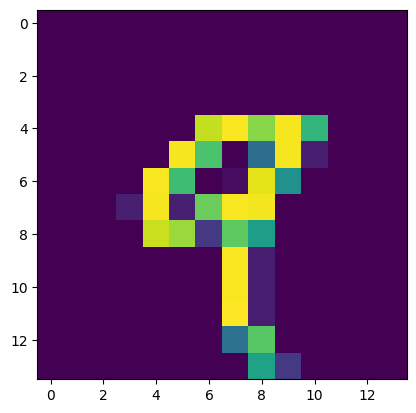

In [ ]:
plt.imshow(train_images[4])
plt.show

In [ ]:
def relu(arr):
    return np.maximum(0, arr)

def softmax(arr):
    arr = np.array(arr, dtype=np.float64)
    shifted = arr - np.max(arr, axis=-1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=-1, keepdims=True)

testdata = np.array([-2.0, -0.5, 0.0, 1.5, 3.0])
batch = np.array([
    [1.0, 2.0, 3.0],
    [1.0, 0.0, -1.0]
])


print(relu(testdata))
print(softmax(batch))

print("Sum of softmax outputs for each row:")
for i in range(len(batch)):
    print(f"Row {i}: {sum(softmax(batch)[i])}")


[0.  0.  0.  1.5 3. ]
[[0.09003057 0.24472847 0.66524096]
 [0.66524096 0.24472847 0.09003057]]
Sum of softmax outputs for each row:
Row 0: 0.9999999999999999
Row 1: 0.9999999999999999


In [ ]:
def cross_entropy(y_true, y_predicted):
    e = 1e-9 # kleine waarde om log(0) te voorkomen
    return -np.mean(np.sum(y_true * np.log(y_predicted + e), axis=1))


ce_1 = cross_entropy(y_true, y_pred)
print(ce_1)


0.2876820711184476


In [ ]:
input_nodes_amount = 196
hidden_nodes_amount = 128
output_nodes_amount = 10

W1 = np.array(np.random.randn(input_nodes_amount, hidden_nodes_amount) * 0.01, dtype="float32")
b1 = np.zeros(hidden_nodes_amount)

W2 = np.array(np.random.randn(hidden_nodes_amount, output_nodes_amount) * 0.01, dtype="float32")
b2 = np.zeros(output_nodes_amount)

In [ ]:
print(f"size kb: {(W1.nbytes + W2.nbytes + b1.nbytes + b2.nbytes)/1000}")

size kb: 106.576


In [ ]:
def forward(X, weight1, bias1, weight2, bias2):
    Z1 = X @ weight1 + bias1
    A1 = relu(Z1)
    Z2 = A1 @ weight2 + bias2
    A2 = softmax(Z2)
    cache = (X, Z1, A1, Z2, A2)
    return (A2, cache)

input_data = train_images_flat[:5]
actual_labels = train_labels_oh[:5]

pred, cache = forward(input_data, W1, b1, W2, b2)


print(actual_labels)
# print(pred.shape)
print(pred)
# print(cache)

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
[[0.09945647 0.10084099 0.10024733 0.0993115  0.09978129 0.09985247
  0.10021481 0.10046174 0.09977926 0.10005413]
 [0.09976188 0.10073377 0.10011879 0.09963312 0.09962955 0.09947347
  0.10027502 0.10045211 0.09948798 0.10043431]
 [0.10010308 0.09995427 0.10043405 0.10029492 0.10006178 0.09959005
  0.10005257 0.09986133 0.09962772 0.10002023]
 [0.09993406 0.10021329 0.10019296 0.09969015 0.10007132 0.10038531
  0.09985382 0.09970323 0.09963243 0.10032342]
 [0.09978418 0.10027464 0.09988582 0.10005179 0.10004817 0.09978603
  0.10023824 0.10003487 0.09974572 0.10015053]]


In [ ]:
def compute_output_gradient(final_prediction, correct_answers):
    N = final_prediction.shape[0] # aantal plaatjes pet batch
    # print(f"Batch size: {N}")
    return (final_prediction - correct_answers) / N

compute_output_gradient(pred, actual_labels)

array([[ 0.02005208,  0.01998864,  0.01993723,  0.01998575,  0.01998733,
        -0.17998687,  0.02004859,  0.01994649,  0.02012443,  0.01991633],
       [-0.17993265,  0.01995112,  0.01991174,  0.02003844,  0.019987  ,
         0.0199939 ,  0.02003343,  0.02000689,  0.0200782 ,  0.01993194],
       [ 0.02003934,  0.01999762,  0.01993243,  0.02005953, -0.18002067,
         0.02001984,  0.01997503,  0.01998788,  0.0200478 ,  0.01996121],
       [ 0.01998223, -0.18003874,  0.020008  ,  0.02001792,  0.01996473,
         0.02002658,  0.02004041,  0.01996413,  0.02011075,  0.01992398],
       [ 0.0200289 ,  0.01997628,  0.01997904,  0.02005945,  0.01999961,
         0.01998539,  0.02001678,  0.01995663,  0.02008454, -0.18008662]])

In [ ]:
def compute_output_gradients(hidden_output, output_gradient):
    dW2 = hidden_output.T @ output_gradient
    db2 = np.sum(output_gradient, axis=0)
    return (dW2, db2)

dw2, db2 = compute_output_gradients(cache[2], compute_output_gradient(pred, actual_labels))

print("dW2 shape:", dw2.shape)
print("db2 shape:", db2.shape)

dW2 shape: (64, 10)
db2 shape: (10,)


In [ ]:
def compute_hidden_gradient(output_gradient, hidden_to_output_weights):
    return output_gradient @ hidden_to_output_weights.T

In [ ]:
def relu_derivative(x):
    return (x > 0).astype(float)

In [ ]:
def compute_hidden_gradients(hidden_gradient, hidden_raw_gradient, input_data):
    dZ1 = hidden_gradient * relu_derivative(hidden_raw_gradient)

    dW1 = input_data.T @ dZ1
    db1 = np.sum(dZ1, axis=0)
    return (dW1, db1)

In [ ]:
def backward(y_true, cache, W2):
    # Tussenwaarden uit de forward pass uitpakken
    X, Z1, A1, Z2, A2 = cache

    # Fout bij de output: voorspelling - juiste antwoord (gemiddeld over de batch)
    output_gradient = compute_output_gradient(A2, y_true)

    # Gradient van output-gewichten W2 en bias b2
    dW2, db2 = compute_output_gradients(A1, output_gradient)

    # Foutsignaal terugsturen naar de hidden-laag via W2
    hidden_gradient = compute_hidden_gradient(output_gradient, W2)

    # Gradient van hidden-gewichten W1 en bias b1 (relu-afgeleide blokkeert inactieve nodes)
    dW1, db1 = compute_hidden_gradients(hidden_gradient, Z1, X)

    # Alle vier de gradienten teruggeven voor de update-stap
    return (dW1, db1, dW2, db2)

In [ ]:
lr = 0.01
batch_size = 256
n = train_images_flat.shape[0]
epochs = 300

print(f"Number of training samples: {n}")

for epoch in range(epochs):

    # train in batches van batch_size
    for start in range(0, n, batch_size):
        b = slice(start, start + batch_size)
        voorspelling, cache = forward(train_images_flat[b], W1, b1, W2, b2)
        dW1, db1, dW2, db2 = backward(train_labels_oh[b], cache, W2)
        W1 -= lr*dW1; b1 -= lr*db1; W2 -= lr*dW2; b2 -= lr*db2

    # einde epoch: loss/acc op de hele set
    pred_all, _ = forward(train_images_flat, W1, b1, W2, b2)
    loss = cross_entropy(train_labels_oh, pred_all)
    acc = np.mean(np.argmax(pred_all, axis=1) == train_labels)
    print(f"Epoch {epoch + 1}, Loss: {loss:.4f}, Acc: {acc:.3f}")

Number of training samples: 60000
Epoch 1, Loss: 2.2932, Acc: 0.305
Epoch 2, Loss: 2.2736, Acc: 0.431
Epoch 3, Loss: 2.2245, Acc: 0.430
Epoch 4, Loss: 2.1118, Acc: 0.442
Epoch 5, Loss: 1.9049, Acc: 0.530
Epoch 6, Loss: 1.6198, Acc: 0.617
Epoch 7, Loss: 1.3413, Acc: 0.685
Epoch 8, Loss: 1.1264, Acc: 0.736
Epoch 9, Loss: 0.9708, Acc: 0.769
Epoch 10, Loss: 0.8574, Acc: 0.791
Epoch 11, Loss: 0.7731, Acc: 0.807
Epoch 12, Loss: 0.7092, Acc: 0.820
Epoch 13, Loss: 0.6598, Acc: 0.830
Epoch 14, Loss: 0.6206, Acc: 0.837
Epoch 15, Loss: 0.5888, Acc: 0.844
Epoch 16, Loss: 0.5626, Acc: 0.849
Epoch 17, Loss: 0.5405, Acc: 0.854
Epoch 18, Loss: 0.5216, Acc: 0.859
Epoch 19, Loss: 0.5052, Acc: 0.862
Epoch 20, Loss: 0.4909, Acc: 0.866
Epoch 21, Loss: 0.4783, Acc: 0.869
Epoch 22, Loss: 0.4671, Acc: 0.872
Epoch 23, Loss: 0.4570, Acc: 0.874
Epoch 24, Loss: 0.4480, Acc: 0.876
Epoch 25, Loss: 0.4397, Acc: 0.878
Epoch 26, Loss: 0.4323, Acc: 0.880
Epoch 27, Loss: 0.4254, Acc: 0.881
Epoch 28, Loss: 0.4191, Acc: 0

In [ ]:
test_pred, _ = forward(test_images_flat, W1, b1, W2, b2)

test_loss = cross_entropy(test_labels_oh, test_pred)
test_acc = np.mean(np.argmax(test_pred, axis=1) == test_labels)

print("Final evaluation:")
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.3f}")

Final evaluation:
Test loss: 0.1592, Test accuracy: 0.953



__tabel 2__ vergelijking algoritmen met nieuwe data
algoritme | Handgemaakte d tree | week 3 ding     |k-NN            | k-means | linear regression | gini d tree | nn keras | nn handgemaakt|
----------|---------------------|-----------------|----------------|---------|-------------------|-------------|----------|---------------|
accuracy top| 27.8%             | 72%             |onbekend        | 93%     | 86.0%             | 88.0%       | 97%      | 98%           |
past op mystery device| ja      | met aanpassingen|met aanpassingen| ja      | ja                | ja          | ja       | met aanpassingen|
beste passende prestaties| 27.8%| 61%             |91%             | 88.3%   | 86.05%            | 81.2%       | 79.5%    | 97.3%         |

## Eindkeuze

### het handgemaakt neuraal netwerk is het beste algoritme

Dit is besloten op basis van de accuracy scores in tabel 2. Waarin te zien is dat het handgemaakte neuraal netwerk de beste presetatie levert op de mystery device.

Binnen het algoritme zijn nog veel aanpassingen te maken. Hieronder zijn be belangrijkse verschillen tussen de handgemaakte NN P opdracht en de mystery device uitgelegd.
- __twee files:__ het trainen en voorspellen wordt op twee verschillende bestanden gedaan. Omdat op de mystery device ook niet getrained kan worden, ivm de geheugenrestricties. Het overzetten van de weights en biases wordt met .npy (binairy) bestanden verzorgd.
- __resize afbeeldingen:__ de P opdracht gebruikt een neuraal netwerk met 784 pixels (28 * 28). De mystery device gebruikt slechts 196 (14 * 14) pixels. hiermee wordt het model significant kleiner.
- __kleinere floats:__ de P opdracht gebruikt 64 bit floats voor de weights en biases. Op de mystery device wordt gebruikt gemaakt van 32 bit floats. Hiermee kan de groote van het model verder worden gereduceerd.
- __image centering:__ omdat het model is getrained op afbeeldingen die naar hun center of mass zijn georieenteerd wordt in de mystery device een extra stap opgenomen in de preprocessing om input naar het midden te verschuiven. Zodat zij beter overeenkomen met de mnist afbeeldingen.
- __PIL voor files uitlezen:__ omdat ook handmatig input moet kunnen worden gegeven op de mystery device is PIL gebruikt om afbeeldingsbestanden om te zetten naar numpy array's. Zo kunnen .png's ook worden herkend. De "self_made_images" folder bied alvast een paar zelf getekende afbeeldingen om mee te experimenteren.  


__figuur 5__ pipeline

            startup                                preprocessing                                                        voorspellings algoritme          terugkoppeling
    bestand wordt ingelezen --> numpy array -|-> minmax normalisatie --> center of mass verplaating --> flattenen -|-> forward pass --> hoogste logit -|-> voorspelling

## Reflectie

### Met Libraries
Ook wanneer extere libraries zouden zijn toegestaan blijft de device zelf de de grote bottleneck. Want door deze libraries zouden de limieten van de device snel worden overschreden. Keras is bijvoorbeeld 1.3 MB. Als ook de limieten van de mystery device worden opgeheven is de keuze voor een neuraal netwerk met Keras snel gemaakt. Dit is eenvoudig te implementeren en scoort hoog in accuarcy.

### Echte Mystery Device
De keuze voor Python geeft momenteel al erg veel problemen. Zoals besproken in het hoofdstuk Encoding/ footprint van Python past de applicatie onmogelijk op de mystery device. Als de applicatie dus daadwerkelijk op de mystery device zou moeten draaien is waarschijnlijk een andere taal nodig met minder overhead zoals Rust of C.

### accuracy VS memory
De originele vraag "Wat is belangrijker: accuracy of memory?" vind ik slecht. Het is mijns inziens geen versus. Maar de vraag hoe veel accuracy kan ik uit mijn memory halen. Zeker omdat de mystery device geen cloud service is, waarbij meer memory meer geld kost, is het nuttig de beschikbare memory zo veel mogelijk te benutten.

### waarom agregaat features weinig toevoegden
In de decision tree opdracht zijn diverse features bedacht. Maar deze blijken in eerder opdrachten nauwelijks positief bij te dragen aan de voorspellingen. Een verklaring hiervoor zou kunnen zijn dat deze features nog altijd vrij direct pixelvlakken beschrijven. Dit doen veel model ook wanneer zij de ruwe pixeldata ontvangen. Een neuraal netwerk zal bijvoorbeeld zelf op zoek naar naar pixelvlakken die nummers beschrijven. Net als de agregaat features, maar dan met meer naukeurigheid.\
Als features die meer zouden toevoegen zijn bijvoorbeeld:
- hoe veel (zwarte) oppervlakten bestaan in een afbeelding.
- waar liggen de zwaartepunten van een afbeelding? (K-means binnen een beeld)
- Bounding boxes

## Taakverdeling
Dit project ontwikelled door: Dani Jurjevic en Rein Schregardus heeft de volgende taakverdeling

0.1 Simulated AI game\
Opdracht door beide individueel gemaakt\
Dani: Recursive tree oplossing\
Rein: Willekeurig keukenjargon aan elkaar plakken

P1 Onderzoek van de database\
Opdracht gemaakt door Rein

P2 Data exploratie\
Opdracht gemaakt door Rein

P3 Small Decision Tree\
Opdracht door beide gemaakt:\
Dani: Decision tree\
Rein: het week 3 ding en aanpassing code Dani

P4 Encoding\
Opdracht door Rein gemaakt

P5 KMeans Clustering\
Opdracht door Rein gemaakt

P6 Linear Regression\
Opdracht door beide individueel gemaakt

P7 Decision Tree met Gini\
Opdracht door Rein gemaakt

P8 Neuraal Netwerk\
Opdracht door beide individueel gemaakt

P9 Activatie functies in Neuraal Netwerk\
Opdracht door beide individueel gemaakt


P10 Neuraal netwerk zonder libraries\
Opdracht gemaakt door Dani\
Dani: Gepresenteerde eindopdacht\
Rein: Diverse gestande pogingen
